## Importing Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

## Data Preprocessing 

In [2]:
# Reading dataset
df = pd.read_csv("online_shoppers_intention.csv")
df.head()

,AcctPagesViewed,AcctPageTime,InfoPagesViewed,InfoPageTime,ProductPagesViewed,ProductPageTime,AvgBounceRate,AvgExitRate,AvgPageValue,ProximityToSpecialDay,VisitMonth,UserOS,UserBrowser,UserRegion,SourceChannel,UserCategory,IsWeekendVisit,MadePurchase
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
rows, cols = df.shape

print("Number of rows:", rows)
print("Number of columns:", cols)

Number of rows: 12330
Number of columns: 18


## Feature Engineering

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   AcctPagesViewed        12330 non-null  int64  
 1   AcctPageTime           12330 non-null  float64
 2   InfoPagesViewed        12330 non-null  int64  
 3   InfoPageTime           12330 non-null  float64
 4   ProductPagesViewed     12330 non-null  int64  
 5   ProductPageTime        12330 non-null  float64
 6   AvgBounceRate          12330 non-null  float64
 7   AvgExitRate            12330 non-null  float64
 8   AvgPageValue           12330 non-null  float64
 9   ProximityToSpecialDay  12330 non-null  float64
 10  VisitMonth             12330 non-null  str    
 11  UserOS                 12330 non-null  int64  
 12  UserBrowser            12330 non-null  int64  
 13  UserRegion             12330 non-null  int64  
 14  SourceChannel          12330 non-null  int64  
 15  UserCategory 

AcctPagesViewed          0
AcctPageTime             0
InfoPagesViewed          0
InfoPageTime             0
ProductPagesViewed       0
ProductPageTime          0
AvgBounceRate            0
AvgExitRate              0
AvgPageValue             0
ProximityToSpecialDay    0
VisitMonth               0
UserOS                   0
UserBrowser              0
UserRegion               0
SourceChannel            0
UserCategory             0
IsWeekendVisit           0
MadePurchase             0
dtype: int64

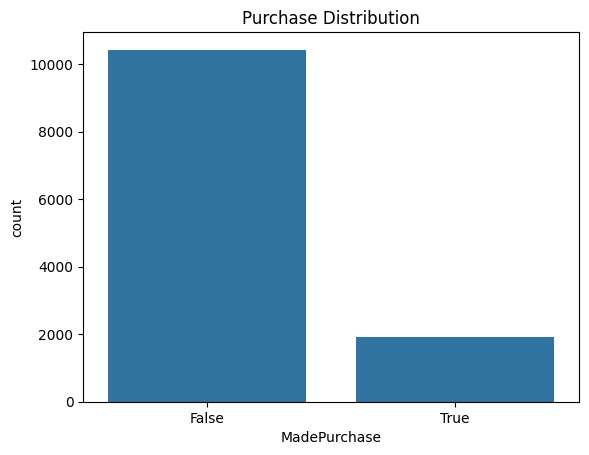

In [5]:
sns.countplot(x='MadePurchase', data=df)
plt.title("Purchase Distribution")
plt.show()

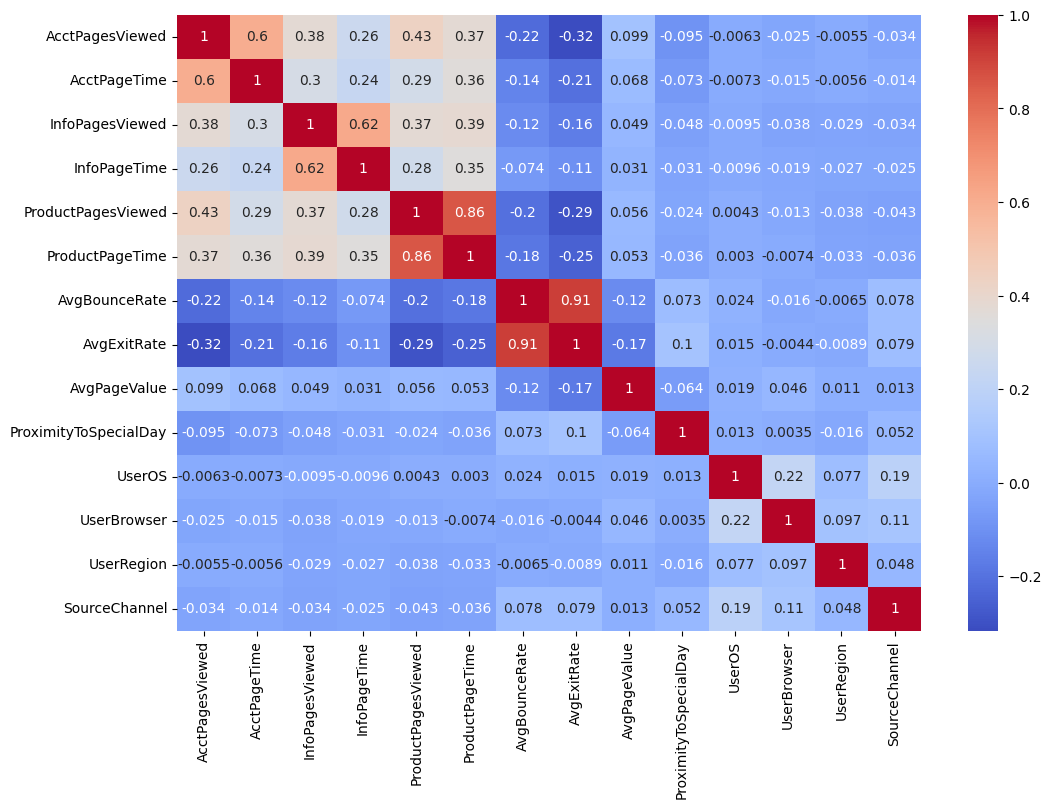

In [6]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [7]:
df.fillna(df.median(numeric_only=True), inplace=True)

,AcctPagesViewed,AcctPageTime,InfoPagesViewed,InfoPageTime,ProductPagesViewed,ProductPageTime,AvgBounceRate,AvgExitRate,AvgPageValue,ProximityToSpecialDay,VisitMonth,UserOS,UserBrowser,UserRegion,SourceChannel,UserCategory,IsWeekendVisit,MadePurchase
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [8]:
df.drop(['UserOS', 'UserBrowser', 'UserRegion'], axis=1, inplace=True)

In [9]:
le = LabelEncoder()

categorical_cols = ['VisitMonth', 'UserCategory', 'IsWeekendVisit']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop('MadePurchase', axis=1)
y = df['MadePurchase']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Building

In [13]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [14]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [15]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Moodel Evaluation

In [16]:
def evaluate_model(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
    plt.show()

Logistic Regression
Accuracy: 0.8698296836982968

Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.98      0.93      2055
        True       0.73      0.34      0.47       411

    accuracy                           0.87      2466
   macro avg       0.81      0.66      0.70      2466
weighted avg       0.86      0.87      0.85      2466



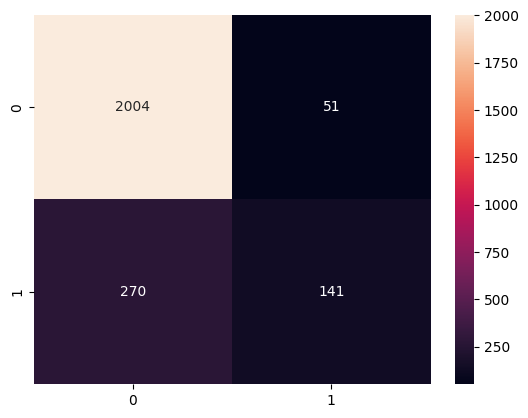

Decision Tree
Accuracy: 0.8588807785888077

Classification Report:
               precision    recall  f1-score   support

       False       0.92      0.91      0.91      2055
        True       0.57      0.60      0.58       411

    accuracy                           0.86      2466
   macro avg       0.75      0.75      0.75      2466
weighted avg       0.86      0.86      0.86      2466



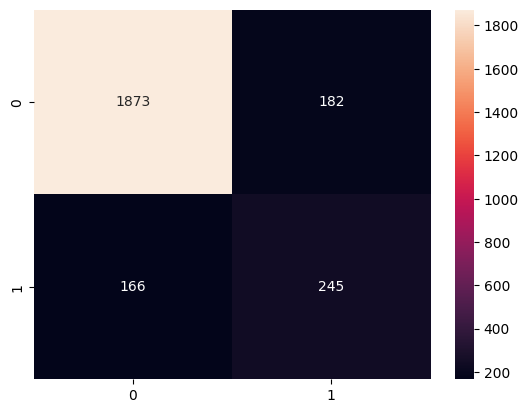

Random Forest
Accuracy: 0.8949716139497161

Classification Report:
               precision    recall  f1-score   support

       False       0.91      0.96      0.94      2055
        True       0.76      0.55      0.63       411

    accuracy                           0.89      2466
   macro avg       0.83      0.76      0.79      2466
weighted avg       0.89      0.89      0.89      2466



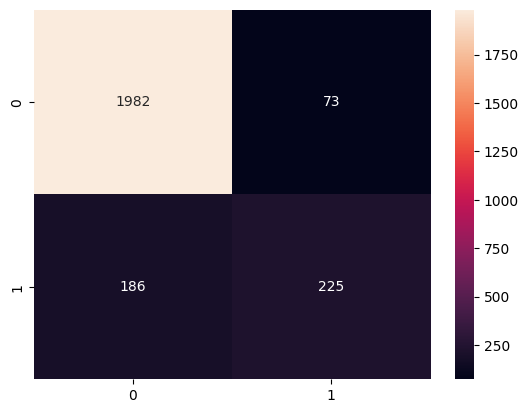

In [17]:
print("Logistic Regression")
evaluate_model(y_test, y_pred_lr)

print("Decision Tree")
evaluate_model(y_test, y_pred_dt)

print("Random Forest")
evaluate_model(y_test, y_pred_rf)

## Hyper Parameter Tuning 

In [18]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [19]:
## Cross Validation

scores = cross_val_score(best_model, X, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.897323600973236


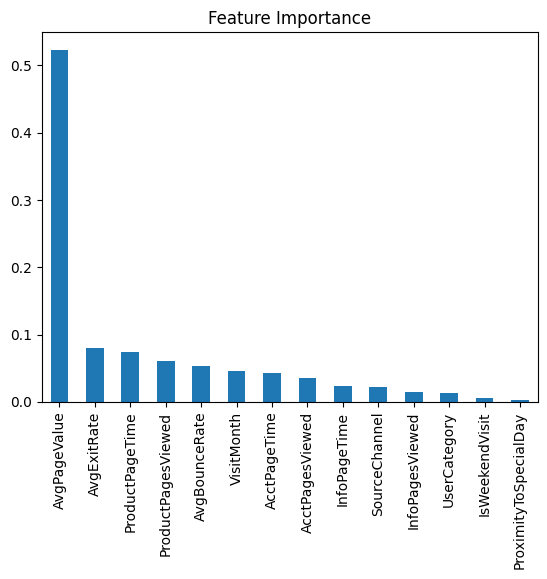

In [20]:
importances = best_model.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

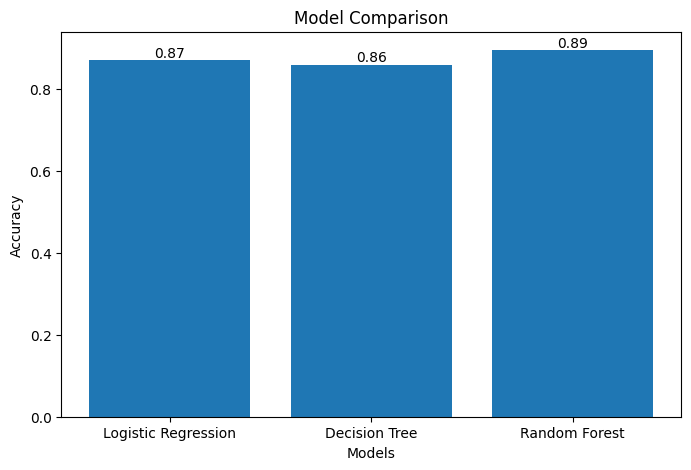


Best Performing Model : Random Forest
Best Accuracy : 89.49716139497161


In [21]:
# Model Comparision & Visualization

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

accuracies = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy
]

# Bar Graph Visualization

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval, 2),
        ha='center',
        va='bottom'
    )
plt.show()

# Best Model

best_accuracy = max(accuracies)
best_model = models[accuracies.index(best_accuracy)]
print("\nBest Performing Model :", best_model)
print("Best Accuracy :", 100 * best_accuracy)